In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, '/workspace')
import experiments.plot_functions as pf

# Visualize ROIs

In [2]:
skip = True
if not skip:
    roi_defs_dir_path = "/workspace/data/nsd/nsd_roi_defs"
    view = pf.visualize_rois(roi_defs_dir_path, hemisphere='right', map_type='flat')

# Fig for papers

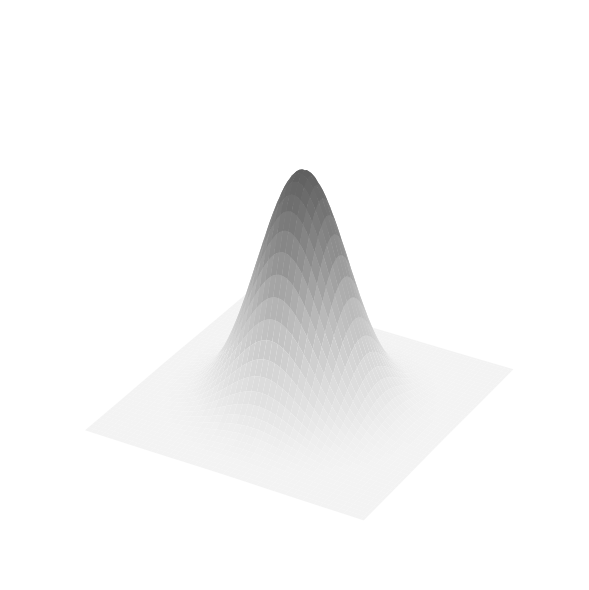

In [3]:
import matplotlib.colors as mcolors
gray_mid = mcolors.LinearSegmentedColormap.from_list(
    "gray_mid", plt.cm.Greys(np.linspace(0.1, 0.7, 256))
)
# Plot gaussian distribution as 3D surface
mean = np.array([0.0, 0.0])
cov = np.array([[1.0, 0.0],
                [0.0, 1.0]])
# density grid
lim = 3.5
xs = np.linspace(-lim, lim, 100)
ys = np.linspace(-lim, lim, 100)
X, Y = np.meshgrid(xs, ys)
pos = np.dstack((X, Y))

inv = np.linalg.inv(cov)
det = np.linalg.det(cov)
diff = pos - mean
expo = np.einsum("...i,ij,...j->...", diff, inv, diff)
Z = np.exp(-0.5 * expo) / (2 * np.pi * np.sqrt(det))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap=gray_mid, linewidth=0,
                       antialiased=True, rstride=2, cstride=2)

ax.set_axis_off()
ax.view_init(elev=30, azim=-60)
plt.tight_layout()
plt.show()

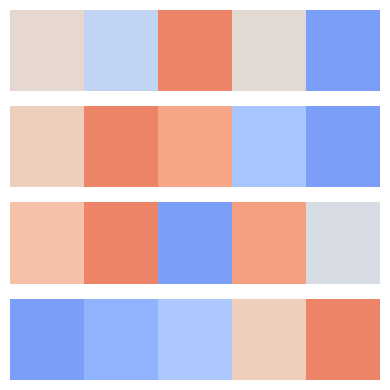

In [ ]:
num_dim = 5
num_data = 4
rng = np.random.default_rng(0)
vecs = [rng.standard_normal(num_dim).reshape(1, -1) for _ in range(num_data)]
greys_nowhite = mcolors.LinearSegmentedColormap.from_list(
    "greys_nowhite", plt.cm.coolwarm(np.linspace(0.2, 0.8, 256))
)
fig, axes = plt.subplots(num_data, 1, figsize=(4, 4))
for ax, vec in zip(axes, vecs):
    ax.imshow(vec, aspect="auto", cmap=greys_nowhite)
    ax.set_axis_off()
plt.tight_layout()
plt.show()
